<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D0%B0_%D0%B0%D0%B2%D1%82%D0%BE%D0%BA%D0%BE%D0%B4%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA%D0%B0_(Autoencoder)_%7C_%D0%94%D0%97_Lite_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задание

Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 – ошибки MSE**<0.034** на скорости обучения **0.001** на **10-й эпохе**.

## Импорт библиотек


In [1]:
# Работа с операционной системой
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Операции с путями
import glob

# Работа с массивами данных
import numpy as np

# Слои
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2DTranspose, concatenate, Activation, MaxPooling2D, Conv2D, BatchNormalization, Concatenate

# Модель
from tensorflow.keras import Model

# Загрузка модели
from tensorflow.keras.models import load_model

# Датасет
from tensorflow.keras.datasets import mnist

# Оптимизатор для обучения модели
from tensorflow.keras.optimizers import Adam

# Коллбэки для выдачи информации в процессе обучения
from tensorflow.keras.callbacks import LambdaCallback

%matplotlib inline

## Утилиты

Функция-коллбэк. Отрисовывает объекты в скрытом пространстве

In [2]:
def ae_on_epoch_end(epoch, logs):
    print('________________________')
    print(f'*** ЭПОХА: {epoch+1}, loss: {logs["loss"]} ***')
    print('________________________')

    # Получение картинки латентного пространства в конце эпохи и запись в файл
    # Задание числа пикселей на дюйм
    plt.figure(dpi=100)

    # Предсказание енкодера на тренировочной выборке
    predict = encoder.predict(X_train)

    # Создание рисунка: множество точек на плоскости 3-х цветов (3-х классов)
    scatter = plt.scatter(predict[:,0,],predict[:,1], c=y_train, alpha=0.6, s=5)

    # Создание легенды
    legend2 = plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    # Сохранение картинки с названием, которого еще нет
    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')

    # Отображение. Без него рисунок не отрисуется
    plt.show()


ae_callback = LambdaCallback(on_epoch_end=ae_on_epoch_end)

Удаление изображений. Применять при обучении новой модели, чтобы не было путаницы в картинках.

In [3]:
def clean():
  # Получение названий всех картинок
  paths = glob.glob('*.jpg')

  # Удаление всех картинок по полученным путям
  for p in paths:
    os.remove(p)

# Удаление всех картинок
clean()

## Загрузка данных

In [4]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Нормировка
X_train = X_train.astype('float32')/255.
X_train = X_train.reshape(-1, 28, 28, 1)

In [6]:
# Выбор визуализируемых классов (цифр) и формирование подвыборок для них по маске
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train])
X_train = X_train[mask]
y_train = y_train[mask]

## Создание модели и обучение

In [7]:
# Ваше решение
# Функция сборки автокодировщика по частям
def create_dense_ae(in_shape, latent_dim):
    # ЭНКОДЕР
    # Вход
    input_img = Input(in_shape)

    # Вспомогательный слой смены формы
    flat_img = Flatten()(input_img)

    x = Dense(1000, activation='relu')(flat_img)


    x = Dense(100, activation='relu')(x)




    # Кодированное полносвязным слоем представление (вектор латентного пространства)
    encoded = Dense(latent_dim, activation='relu')(x)

    # ДЕКОДЕР
    # Вход
    input_encoded = Input(shape=(latent_dim,))

    # Раскодированное другим полносвязным слоем изображение в виде плоского вектора
    flat_decoded = Dense(in_shape[0] * in_shape[1], activation='sigmoid')(input_encoded)

    # Приведение формы раскодированных данных к форме входа
    decoded = Reshape(in_shape)(flat_decoded)

    # Модели, в конструктор первым аргументом передаются входные слои, а вторым выходные слои
    # Другие модели можно так же использовать, как и слои
    encoder = Model(input_img, encoded, name='encoder')
    decoder = Model(input_encoded, decoded, name='decoder')

    # Построение модели автокодировщика (внутри двойное преобразование - сжатие/разжатие)
    autoencoder = Model(input_img, decoder(encoder(input_img)), name="autoencoder")

    # Возврат трех собранных моделей
    return encoder, decoder, autoencoder

In [8]:
def model_check(model):
  # Входная форма
  input_shape = model.input.shape[1:]

  # Выходная форма
  output_shape = model.output.shape[1:]

  # Сравнение
  assert input_shape == output_shape, 'Вход и выход не совпадают по форме'

In [9]:
# Создание трех моделей - составных частей автокодировщика и самого автокодировщика
encoder, decoder, autoencoder = create_dense_ae(in_shape=X_train.shape[1:3], latent_dim=2)
# проверка автокодировщик ли это
model_check(autoencoder)

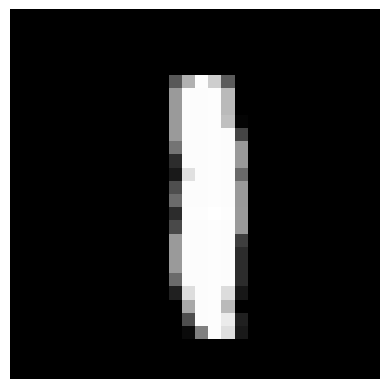

In [10]:
# Выбор случайного изображения из тренировочной выборки и показ его
test_img = X_train[np.random.randint(len(X_train))]
plt.imshow(test_img.reshape(X_train.shape[1:3]), cmap='gray')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
[[0.48703924 0.19249146]]


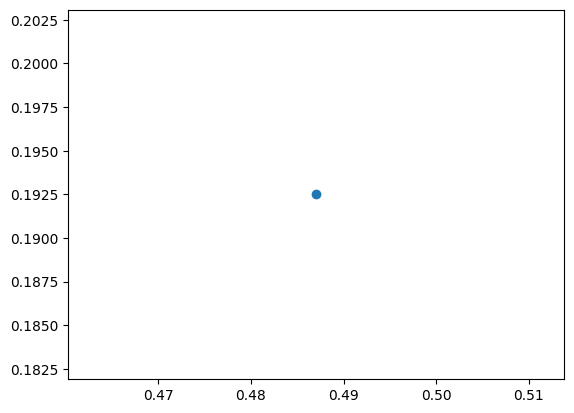

In [11]:
# Получение предсказания энкодера (двумерная точка в латентном пространстве)
point = encoder.predict(test_img[None,...])

# Вывод координат точки в числах и на графике
print(point)
scatter = plt.scatter(point[0,0], point[0,1])
plt.show()

In [12]:
# Компиляция модели с выбранным оптимизатором и функцией потерь
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

Epoch 1/10
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0814________________________
*** ЭПОХА: 1, loss: 0.05655289813876152 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


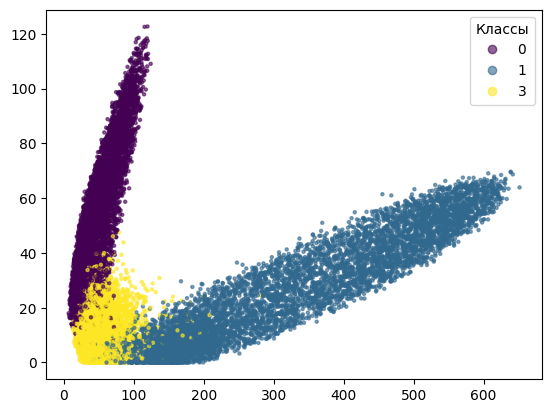

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0813
Epoch 2/10
1162/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0462________________________
*** ЭПОХА: 2, loss: 0.045785389840602875 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


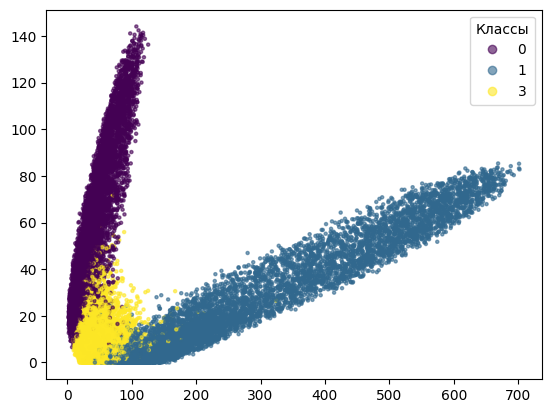

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0462
Epoch 3/10
1171/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0447________________________
*** ЭПОХА: 3, loss: 0.04442097246646881 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


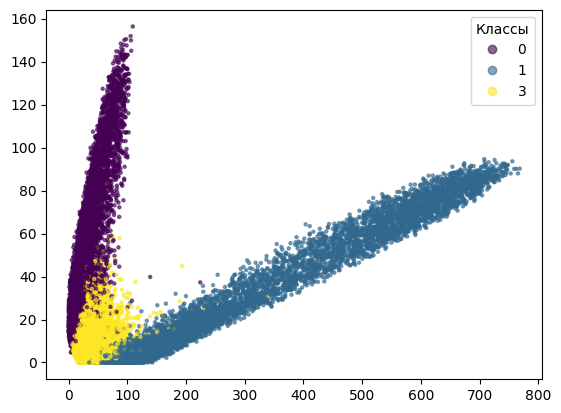

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0447
Epoch 4/10
1160/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0437________________________
*** ЭПОХА: 4, loss: 0.04359212517738342 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


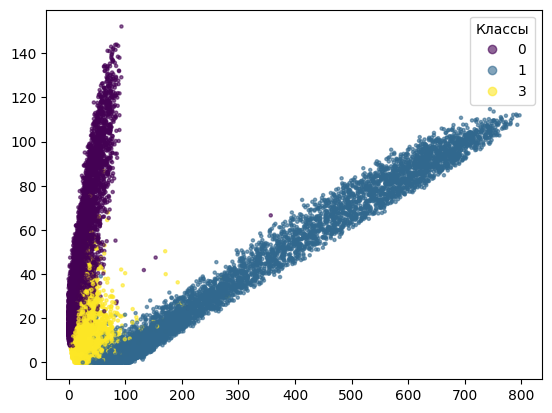

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0437
Epoch 5/10
1168/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0431________________________
*** ЭПОХА: 5, loss: 0.04305320978164673 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


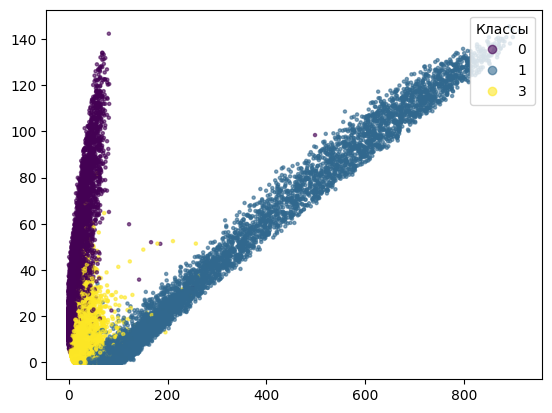

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0431
Epoch 6/10
1161/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0427________________________
*** ЭПОХА: 6, loss: 0.04271513596177101 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


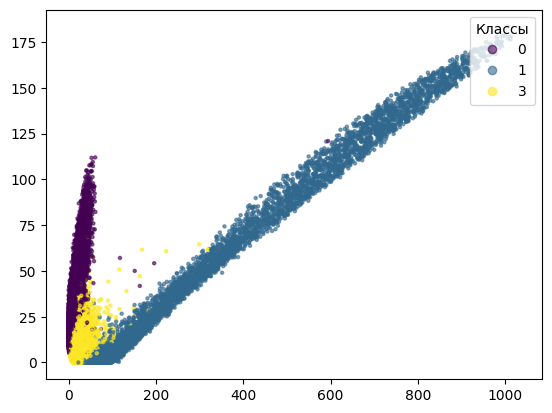

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0427
Epoch 7/10
1173/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0423________________________
*** ЭПОХА: 7, loss: 0.04251512885093689 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


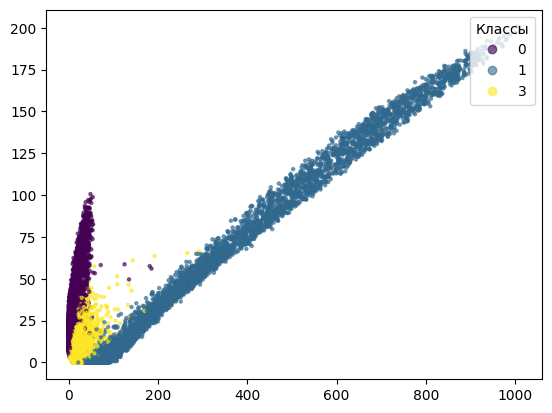

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0423
Epoch 8/10
1155/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0424________________________
*** ЭПОХА: 8, loss: 0.04232234135270119 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


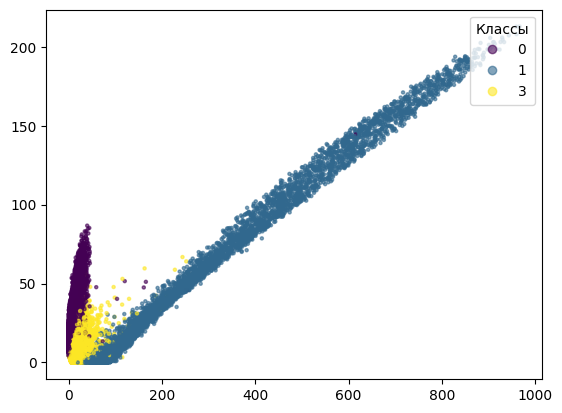

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0424
Epoch 9/10
1156/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0422________________________
*** ЭПОХА: 9, loss: 0.042123135179281235 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


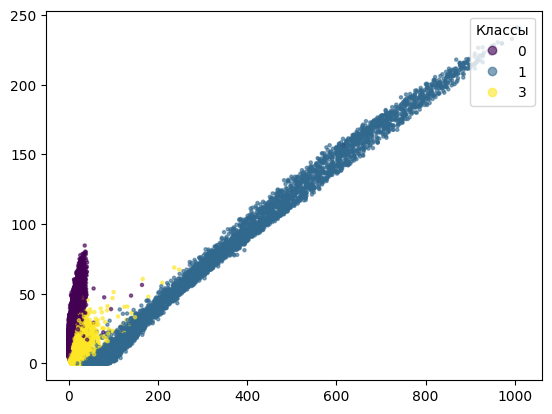

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0422
Epoch 10/10
1170/1175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0420________________________
*** ЭПОХА: 10, loss: 0.04192894324660301 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


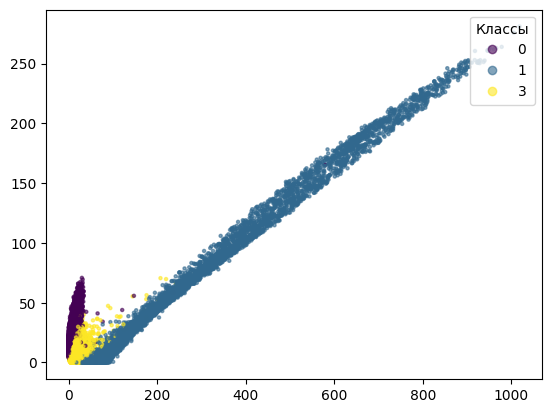

1175/1175 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0420


In [13]:
# Обучение автокодировщика с протоколом работы
autoencoder.fit(X_train, X_train,
                epochs=10,
                batch_size=16,
                shuffle=True,
                callbacks = [ae_callback],
                verbose=1)

In [ ]:
# Удаление всех картинок
clean()